# CAPRA on manually assembled single-cell data

This notebook constructs a small `AnnData` with **704 cells × 512 human genes**.
It simulates overdispersed counts, applies library-size normalization and
`log1p`, then uses the bundled genuine GenePT vectors for all 512 output genes,
including seven perturbation targets. The expression is simulated; replace the construction cell with your
measured data when using the same workflow on your study.

Set `condition_key` and `perturbation_key` in the configuration cell to the matching `adata.obs` columns.

The notebook sets explicit train/validation/test conditions and runs the full
CAPRA preparation, fitting, prediction, export and checkpoint-reload flow on GPU. The gene vectors come from [GenePT](https://doi.org/10.5281/zenodo.10833191).

Expected prediction: **32 cells × 512 genes** in `predictions.h5ad`, with run details in `summary.json` and a reloadable checkpoint under `demo/outputs/demo_own_data/`.

## Run this notebook

Install CAPRA using the repository README and register the **Python (CAPRA)** kernel.
From the repository root, start `python -m notebook`, open this notebook, select
**Python (CAPRA)**, and choose **Restart Kernel and Run All Cells**.
The input files are bundled in `demo/data/`; no additional data download is needed.
This example runs two training epochs on a CUDA GPU.

The saved cell outputs show a completed run. After rerunning, the final cell should
print `Checkpoint reload verified` and `Completed`. The prediction dimensions and
output paths are listed above.

Reference runtime on Ubuntu 20.04.6 with an NVIDIA RTX 3090: approximately 10 seconds, including kernel startup.


In [1]:
from pathlib import Path
import json
import os
import platform
import sys
import time
import warnings

started = time.perf_counter()

# Launch from the repository root or demo/. Outputs can be redirected without
# editing this notebook; input data and source files are never overwritten.
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
repo_root = next((p for p in candidates if (p / 'capra/frame.py').is_file()), None)
if repo_root is None:
    raise RuntimeError('Launch this notebook from the repository root or demo/.')
sys.path.insert(0, str(repo_root / 'capra'))

import anndata as ad
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from frame import CAPRA, CAPRAData, load_gene_embedding_table

# Scanpy's DEG table assembly emits repeated pandas fragmentation warnings.
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning,
                        message='DataFrame is highly fragmented.*')
torch.set_num_threads(min(4, os.cpu_count() or 1))
timings = {}
print('Python:', platform.python_version(), '| PyTorch:', torch.__version__)
print('Kernel executable:', Path(sys.executable).name)


Python: 3.9.7 | PyTorch: 2.3.0+cu118
Kernel executable: python


In [2]:
demo_name = 'demo_own_data'
condition_key = 'condition'       # input adata.obs column
perturbation_key = 'perturbation'  # input adata.obs column
seed = 24
max_epochs, n_pred, val_n_pred, num_workers = 2, 16, 16, 0
accelerator = 'gpu'
if not torch.cuda.is_available():
    raise RuntimeError('A CUDA GPU is required for this demo.')
output_base = Path(os.environ.get('CAPRA_DEMO_OUTPUT_ROOT', str(repo_root / 'demo/outputs'))).resolve()
output_dir = output_base / demo_name
print('GPU:', torch.cuda.get_device_name(0))
print('Selected obs keys:', condition_key, perturbation_key)


GPU: NVIDIA GeForce RTX 3090
Selected obs keys: condition perturbation


## 1. Construct a small single-cell dataset


In [3]:
stage_started = time.perf_counter()
import scanpy as sc
from scipy import sparse
rng = np.random.default_rng(seed)
embedding_path = repo_root / 'demo/data/norman_example_genept_embeddings.pkl'
if not embedding_path.is_file():
    raise FileNotFoundError(embedding_path)
# Gene symbols and perturbation vectors come from the bundled GenePT table.
all_embeddings = load_gene_embedding_table(embedding_path, add_control=False)
perturbation_genes = ['CEBPB', 'FOS', 'GATA1', 'IRF1', 'JUN', 'MYC', 'STAT1']
assert set(perturbation_genes).issubset(all_embeddings.index)
genes = perturbation_genes + [g for g in all_embeddings.index if g not in perturbation_genes][:505]
assert len(genes) == 512 and len(set(genes)) == 512
embedding_table = all_embeddings.loc[genes].copy()
embedding_table.loc['ctrl'] = np.zeros(embedding_table.shape[1], dtype=np.float32)
# Embeddings cover both perturbation targets and output genes.
# Explicit split with a held-out single and a held-out double condition.
splits = {
    'train': perturbation_genes[:5] + ['CEBPB+FOS'],
    'val': ['MYC'],
    'test': ['STAT1', 'CEBPB+STAT1'],
}
conditions = ['control'] + splits['train'] + splits['val'] + splits['test']
# Gamma-Poisson counts give variable library sizes and overdispersion.
gene_abundance = rng.lognormal(mean=-0.6, sigma=1.0, size=len(genes))
blocks, labels = [], []
for condition in conditions:
    n_cells = 128 if condition == 'control' else 64
    fold = np.ones(len(genes), dtype=np.float64)
    if condition != 'control':
        for gene in condition.split('+'):
            position = genes.index(gene)
            fold[position] *= 0.35
            fold[32 + position:64 + position] *= 1.7
            fold[96 + position:112 + position] *= 0.65
    library_factor = rng.lognormal(mean=0, sigma=0.45, size=(n_cells, 1))
    mean_counts = gene_abundance[None, :] * fold[None, :] * library_factor
    overdispersed_rate = rng.gamma(shape=2.0, scale=mean_counts / 2.0)
    counts = rng.poisson(overdispersed_rate).astype(np.float32)
    blocks.append(sparse.csr_matrix(counts))
    labels.extend([condition] * n_cells)
obs = pd.DataFrame(
    {condition_key: labels, perturbation_key: labels},
    index=[f'cell_{i:04d}' for i in range(len(labels))],
)
adata = ad.AnnData(X=sparse.vstack(blocks, format='csr'), obs=obs,
                 var=pd.DataFrame(index=genes))
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.uns['demo_provenance'] = 'Simulated gamma-Poisson counts; genuine gene-indexed GenePT vectors.'
assert adata.shape == (704, 512)
print('Manual AnnData:', adata.shape, 'sparse:', sparse.issparse(adata.X))
print('Real GenePT gene vectors:', embedding_table.shape)
print('Explicit splits:', splits)
timings['input_construction_seconds'] = time.perf_counter() - stage_started
display(adata.obs[[condition_key, perturbation_key]].head())


Manual AnnData: (704, 512) sparse: True
Real GenePT gene vectors: (513, 3072)
Explicit splits: {'train': ['CEBPB', 'FOS', 'GATA1', 'IRF1', 'JUN', 'CEBPB+FOS'], 'val': ['MYC'], 'test': ['STAT1', 'CEBPB+STAT1']}


,condition,perturbation
cell_0000,control,control
cell_0001,control,control
cell_0002,control,control
cell_0003,control,control
cell_0004,control,control


## Replace the construction cell with your data

Provide a processed `AnnData` with normalized `log1p` expression in `X`,
unique gene-symbol `var_names`, and labels in the `adata.obs` columns selected by `condition_key`
and `perturbation_key` in the configuration cell. Load your GenePT table indexed by perturbation gene and set explicit
train/validation/test condition lists. The remaining cells run unchanged.


## 2. Prepare data and response anchors


In [4]:
stage_started = time.perf_counter()
capra_data = CAPRAData(
    adata=adata, embedding_table=embedding_table, study_name=demo_name,
    condition_key=condition_key, perturbation_key=perturbation_key,
)
capra_data.harmonize_perturbation_metadata()
capra_data.register_evaluation_partitions(split_dict=splits)
capra_data.estimate_trainval_deg_reference(method='t-test')
assert not (set(capra_data.deg_frames_by_condition) & set(splits['test']))
capra_data.build_control_relative_training_state(topk_deg=100, knn_topk=5, knn_temperature=12.0)
print('Train/val/test conditions:', {k: len(v) for k, v in capra_data.splits.items()})
print('Training response bank:', sorted(capra_data.assets.train_single_delta))
timings['data_preparation_seconds'] = time.perf_counter() - stage_started


Train/val/test conditions: {'train': 6, 'val': 1, 'test': 2}
Training response bank: ['CEBPB', 'FOS', 'GATA1', 'IRF1', 'JUN']


## 3. Train CAPRA


In [5]:
stage_started = time.perf_counter()
model = CAPRA(capra_data)
model.fit_capra_response_operator(
    output_dir=output_dir / 'results', run_name=f'{demo_name}_seed{seed}',
    n_epochs=max_epochs, min_epochs=1, seed=seed,
    accelerator=accelerator, precision='16-mixed', num_workers=num_workers,
    pin_memory=True, val_n_pred=val_n_pred,
)
timings['training_seconds'] = time.perf_counter() - stage_started


CAPRA training | epoch 1/2 | train_loss=3.4609 | val_unseen_loss=0.4592 | monitor=0.3514 | patience=0/10


CAPRA training | epoch 2/2 | train_loss=3.4578 | val_unseen_loss=0.4585 | monitor=0.3502 | patience=0/10


## 4. Predict held-out perturbations


In [6]:
stage_started = time.perf_counter()
test_conditions = list(capra_data.splits['test'])
predictions = model.generate_counterfactual_profiles(pert_list=test_conditions, n_pred=n_pred)
timings['prediction_seconds'] = time.perf_counter() - stage_started
for condition, matrix in predictions.items():
    print(condition, matrix.shape)


CEBPB+STAT1 (16, 512)
STAT1 (16, 512)


## 5. Inspect the predicted response

Compare the predicted and measured means for one held-out perturbation.
The table shows ten genes with the largest measured control-relative responses;
the scatter plot shows all output genes.


Held-out condition: CEBPB+STAT1


,observed_mean,predicted_mean,observed_delta,predicted_delta
gene,,,,
ACAA1,3.3564,3.3854,1.9188,1.9479
CEBPB,1.3056,1.8317,-1.7692,-1.2431
ADCK1,1.2802,2.4307,-1.5185,-0.3679
ABL2,2.3298,2.1556,1.4827,1.3085
ACOX1,4.2425,3.8122,1.4124,0.9822
ABRACL,4.1093,4.2336,1.3691,1.4935
ABI2,4.8203,5.0011,1.3533,1.5341
ACAD10,4.5041,4.6311,1.3521,1.4790
ACAT2,2.7028,1.0973,1.3330,-0.2725


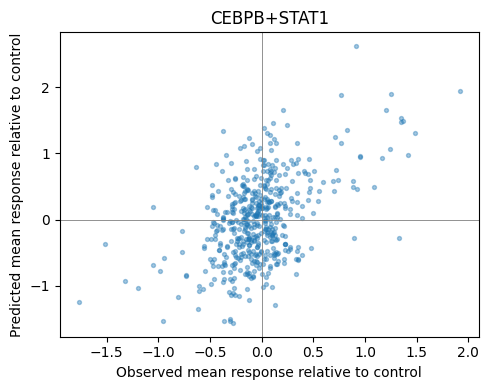

In [7]:
# Inspect the measured and predicted mean responses for one held-out condition.
from IPython.display import display
import matplotlib.pyplot as plt
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

condition = test_conditions[0]
canonical_labels = capra_data.adata.obs['perturbation'].astype(str)
control_mean = np.asarray(capra_data.adata[canonical_labels == 'control'].X.mean(axis=0)).ravel()
observed_mean = np.asarray(capra_data.adata[canonical_labels == condition].X.mean(axis=0)).ravel()
predicted_mean = predictions[condition].mean(axis=0)
response_table = pd.DataFrame({
    'observed_mean': observed_mean,
    'predicted_mean': predicted_mean,
    'observed_delta': observed_mean - control_mean,
    'predicted_delta': predicted_mean - control_mean,
}, index=capra_data.adata.var_names)
response_table.index.name = 'gene'
strongest = response_table['observed_delta'].abs().nlargest(10).index
print('Held-out condition:', condition)
display(response_table.loc[strongest].round(4))
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(response_table['observed_delta'], response_table['predicted_delta'], s=8, alpha=0.4)
ax.axhline(0, color='grey', linewidth=0.6)
ax.axvline(0, color='grey', linewidth=0.6)
ax.set(xlabel='Observed mean response relative to control',
       ylabel='Predicted mean response relative to control', title=condition)
fig.tight_layout()
plt.show()


## 6. Save predictions and run metadata


In [8]:
stage_started = time.perf_counter()
blocks = []
for condition, matrix in predictions.items():
    assert matrix.shape == (n_pred, capra_data.adata.n_vars)
    assert np.isfinite(matrix).all(), f'Non-finite prediction: {condition}'
    obs = pd.DataFrame(
        {'condition': condition, 'perturbation': condition, 'Expcategory': 'imputed'},
        index=[f'{condition}_pred_{i}' for i in range(len(matrix))],
    )
    blocks.append(ad.AnnData(
        X=matrix.astype(np.float32, copy=False), obs=obs,
        var=pd.DataFrame(index=capra_data.adata.var_names.copy()),
    ))
prediction_adata = ad.concat(blocks, merge='same')
assert prediction_adata.var_names.equals(capra_data.adata.var_names)
prediction_adata.uns['demo'] = {'name': demo_name, 'seed': seed}
output_dir.mkdir(parents=True, exist_ok=True)
prediction_path = output_dir / 'predictions.h5ad'
prediction_adata.write_h5ad(prediction_path)
timings['export_seconds'] = time.perf_counter() - stage_started
summary = {
    'demo': demo_name, 'seed': seed,
    'input_shape': list(capra_data.adata.shape),
    'split_conditions': {key: len(value) for key, value in capra_data.splits.items()},
    'predicted_conditions': list(predictions),
    'prediction_shape': list(prediction_adata.shape),
    'n_pred_per_condition': n_pred,
    'best_checkpoint': str(Path(model.fitted['metrics']['best_checkpoint']).relative_to(output_dir)),
    'epochs_completed': model.fitted['metrics']['epochs_completed'],
    'timings': timings,
    'total_seconds': time.perf_counter() - started,
    'environment': {
        'python': platform.python_version(), 'platform': platform.platform(),
        'torch': torch.__version__, 'numpy': np.__version__, 'pandas': pd.__version__,
        'device': model.fitted['metrics']['runtime']['device'],
        'torch_threads': torch.get_num_threads(),
    },
    'training': {
        'max_epochs': max_epochs, 'val_n_pred': val_n_pred,
        'num_workers': num_workers, 'batch_size': 192,
    },
}
(output_dir / 'summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved predictions:', prediction_path.relative_to(repo_root)
      if prediction_path.is_relative_to(repo_root) else prediction_path)
print('Prediction shape:', prediction_adata.shape)
print('Timings (seconds):', {k: round(v, 2) for k, v in timings.items()})
print('Total run seconds:', round(summary['total_seconds'], 2))


Saved predictions: demo/outputs/demo_own_data/predictions.h5ad
Prediction shape: (32, 512)
Timings (seconds): {'input_construction_seconds': 0.29, 'data_preparation_seconds': 0.26, 'training_seconds': 3.88, 'prediction_seconds': 0.01, 'export_seconds': 0.02}
Total run seconds: 7.3


## 7. Reload the checkpoint and verify predictions


In [9]:
# Reload with the same data assets; no fitting occurs in this cell.
stage_started = time.perf_counter()
checkpoint = model.fitted['metrics']['best_checkpoint']
loaded = CAPRA(capra_data)
loaded.load_capra_response_operator(checkpoint, accelerator=accelerator, output_dir=output_dir / 'results')
first_condition = test_conditions[0]
reloaded = loaded.generate_counterfactual_profiles(
    pert_list=[first_condition], n_pred=n_pred, sampling_state=seed,
)[first_condition]
np.testing.assert_allclose(reloaded, predictions[first_condition], rtol=1e-5, atol=1e-5)
summary['checkpoint_reload_verified'] = True
summary['timings']['reload_seconds'] = time.perf_counter() - stage_started
summary['total_seconds'] = time.perf_counter() - started
(output_dir / 'summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Checkpoint reload verified:', first_condition)
print('Completed:', demo_name)
print('Prediction file:', prediction_path.relative_to(repo_root)
      if prediction_path.is_relative_to(repo_root) else prediction_path)
print('Verified prediction shape:', prediction_adata.shape)
print('End-to-end seconds:', round(summary['total_seconds'], 2))


Checkpoint reload verified: CEBPB+STAT1
Completed: demo_own_data
Prediction file: demo/outputs/demo_own_data/predictions.h5ad
Verified prediction shape: (32, 512)
End-to-end seconds: 7.43
